## Imports and Setup


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)


## Load Data and Stock Selection


In [ ]:
# Load cleaned price data
prices = pd.read_csv(
    "./dataset/cleaned_data.csv", 
    parse_dates=["Date"], 
    index_col="Date"
)

print("Loaded price data:", prices.shape)
print("Date range:", prices.index.min(), "to", prices.index.max())
print("Total stocks:", len(prices.columns))

# Load sector mapping
sector_df = pd.read_csv("./dataset/stock_sectors.csv")
stock_sectors = dict(zip(sector_df['Symbol'], sector_df['Sector']))

# Use ALL stocks for Stage 4 (ML discovery scales linearly, unlike Stage 3's pairwise tests)
selected_tickers = prices.columns.tolist()

# Use all prices (no subsetting needed)
prices_subset = prices.copy()

# Show sector breakdown
selected_sectors = [stock_sectors.get(t, 'Unknown') for t in selected_tickers]
sector_counts = pd.Series(selected_sectors).value_counts()
print("\nSector breakdown:")
for sector, count in sector_counts.items():
    print(" ", sector + ":", count, "stocks")

Loaded price data: (3905, 432)
Date range: 2010-01-04 00:00:00 to 2024-12-20 00:00:00
Total stocks: 432

Sector breakdown:
  Financials: 68 stocks
  Industrials: 62 stocks
  Healthcare: 49 stocks
  Information Technology: 47 stocks
  Consumer Discretionary: 45 stocks
  Consumer Staples: 32 stocks
  Real Estate: 29 stocks
  Utilities: 29 stocks
  Materials: 22 stocks
  Unknown: 17 stocks
  Communication Services: 16 stocks
  Energy: 16 stocks


## Compute Log Returns


In [ ]:
# Compute log returns
log_returns = np.log(prices_subset / prices_subset.shift(1)).dropna()

print("Computed log returns:", log_returns.shape)
print("Date range:", log_returns.index.min(), "to", log_returns.index.max())
print("Missing values:", log_returns.isna().sum().sum())

# Handle any remaining missing values
log_returns = log_returns.fillna(method='ffill').fillna(method='bfill')

print("\nLog returns statistics:")
print(log_returns.describe().T[['mean', 'std', 'min', 'max']].head(10))


Computed log returns: (3904, 432)
Date range: 2010-01-05 00:00:00 to 2024-12-20 00:00:00
Missing values: 0

Log returns statistics:
          mean       std       min       max
GNRC  0.000640  0.026572 -0.292250  0.226264
CHTR  0.000591  0.018555 -0.180461  0.153747
MTCH  0.000449  0.025437 -0.249648  0.216437
NDAQ  0.000626  0.015586 -0.137063  0.130180
WFC   0.000242  0.018554 -0.172779  0.135707
WM    0.000460  0.011607 -0.117897  0.086636
WELL  0.000266  0.017964 -0.279654  0.208467
WMB   0.000284  0.023656 -0.427911  0.295550
MU    0.000542  0.029270 -0.220878  0.210611
NDSN  0.000485  0.018274 -0.202227  0.179788


## Normalize Log Returns


Normalized log returns: (3904, 432)
Mean (should be ~0): -2.4150652763798233e-18
Std (should be ~1): 1.0001280983800809


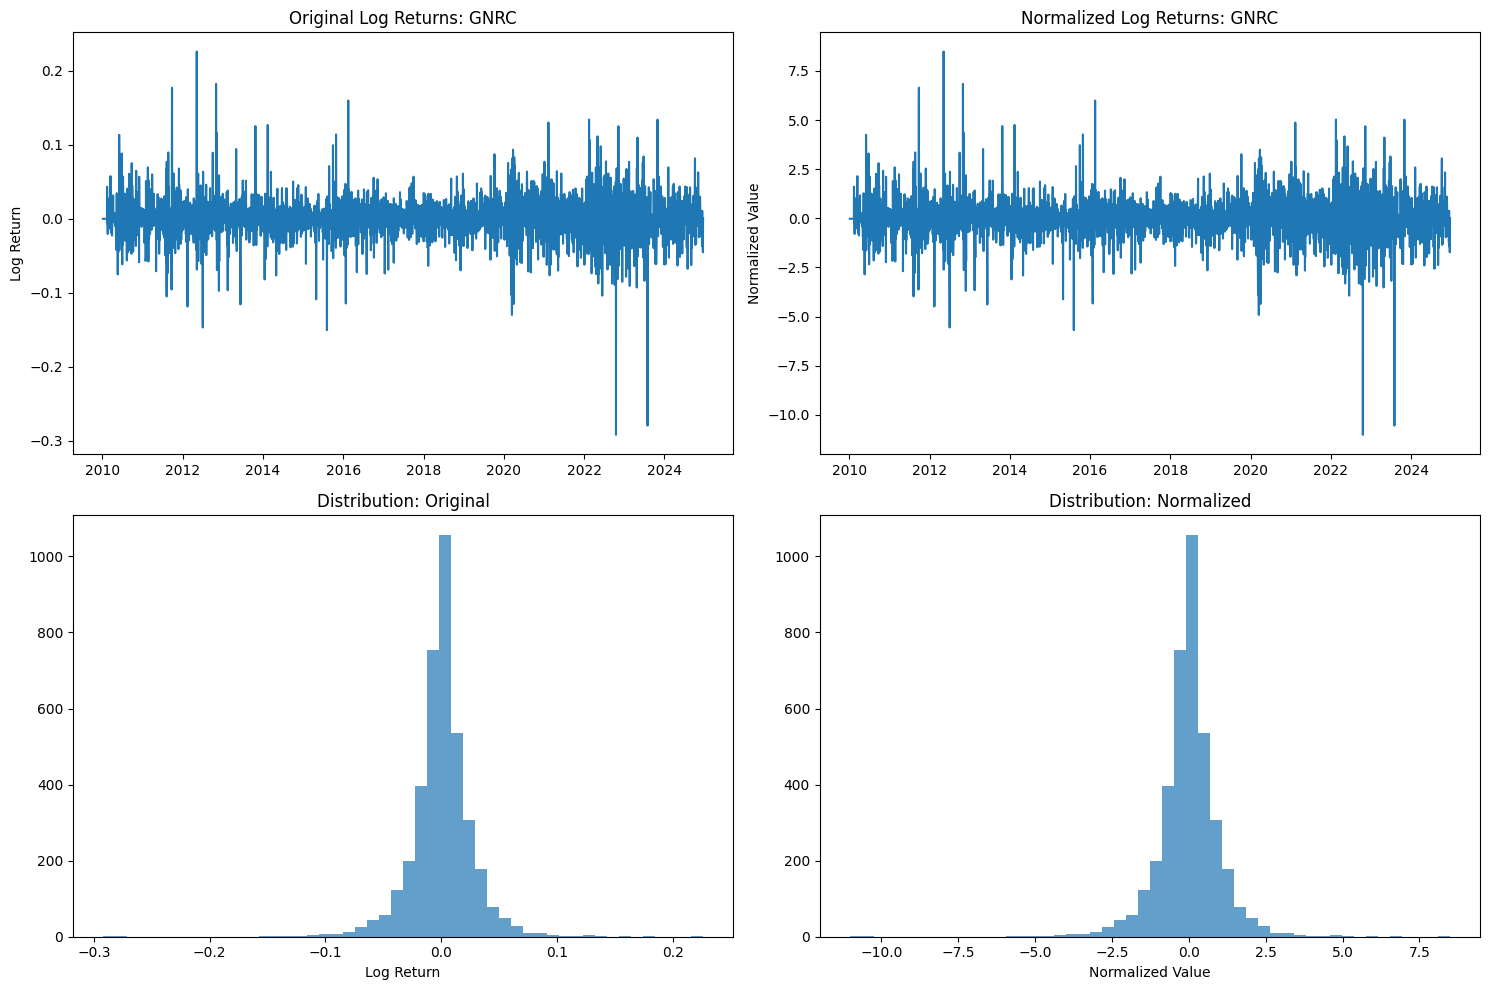

In [ ]:
# Normalize log returns for autoencoder training
scaler = StandardScaler()
log_returns_scaled = scaler.fit_transform(log_returns)

log_returns_normalized = pd.DataFrame(
    log_returns_scaled,
    index=log_returns.index,
    columns=log_returns.columns
)

print("Normalized log returns:", log_returns_normalized.shape)
print("Mean (should be ~0):", log_returns_normalized.mean().mean())
print("Std (should be ~1):", log_returns_normalized.std().mean())

# Visualize normalization effect
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sample_ticker = selected_tickers[0]

axes[0, 0].plot(log_returns.index, log_returns[sample_ticker])
axes[0, 0].set_title('Original Log Returns: ' + sample_ticker)
axes[0, 0].set_ylabel('Log Return')

axes[0, 1].plot(log_returns_normalized.index, log_returns_normalized[sample_ticker])
axes[0, 1].set_title('Normalized Log Returns: ' + sample_ticker)
axes[0, 1].set_ylabel('Normalized Value')

axes[1, 0].hist(log_returns[sample_ticker].dropna(), bins=50, alpha=0.7)
axes[1, 0].set_title('Distribution: Original')
axes[1, 0].set_xlabel('Log Return')

axes[1, 1].hist(log_returns_normalized[sample_ticker].dropna(), bins=50, alpha=0.7)
axes[1, 1].set_title('Distribution: Normalized')
axes[1, 1].set_xlabel('Normalized Value')

plt.tight_layout()
plt.show()


## Prepare Data for Autoencoder


In [ ]:
# Prepare data for autoencoder training
X = log_returns_normalized.values.T
print("Prepared data for autoencoder:", X.shape)
print("Shape: (n_stocks=" + str(X.shape[0]) + ", n_time_steps=" + str(X.shape[1]) + ")")
print("Each row represents one stock's normalized log return time series")

print("\nData verification:")
print("Min value:", X.min())
print("Max value:", X.max())
print("Mean:", X.mean())
print("Std:", X.std())


Prepared data for autoencoder: (432, 3904)
Shape: (n_stocks=432, n_time_steps=3904)
Each row represents one stock's normalized log return time series

Data verification:
Min value: -56.204515241986186
Max value: 19.016008623627627
Mean: -5.123069208956399e-18
Std: 1.0


## Build Autoencoder Model


In [ ]:
# Build autoencoder architecture
input_dim = X.shape[1]
encoding_dim = 10

# Encoder
input_layer = keras.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(32, activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dense(input_dim, activation='linear')(decoded)

# Autoencoder model
autoencoder = keras.Model(input_layer, decoded)

# Encoder model (to get embeddings)
encoder = keras.Model(input_layer, encoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Autoencoder model built")
print("\nModel architecture:")
autoencoder.summary()

print("\nModel configuration:")
print("Input dimension:", input_dim)
print("Encoding dimension:", encoding_dim)
print("Compression ratio:", input_dim/encoding_dim)


Autoencoder model built

Model architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3904)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       249,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3904)           │       253,760 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 508,554 (1.94 MB)

 Trainable params: 508,554 (1.94 MB)

 Non-trainable params: 0 (0.00 B)


Model configuration:
Input dimension: 3904
Encoding dimension: 10
Compression ratio: 390.4


## Train Autoencoder


Training autoencoder...
Epochs: 100
Batch size: 32
Validation split: 0.2
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.9605 - mae: 0.6477 - val_loss: 0.7700 - val_mae: 0.5696 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7225 - mae: 0.5486 - val_loss: 0.6824 - val_mae: 0.5319 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6607 - mae: 0.5254 - val_loss: 0.6445 - val_mae: 0.5174 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6280 - mae: 0.5129 - val_loss: 0.6104 - val_mae: 0.5016 - learning_rate: 0.0010
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6015 - mae: 0.5016 - val_loss: 0.5873 - val_mae: 0.4898 - learning_rate: 0.0010
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5829 - mae: 0.4930 - val_loss: 0.5775 - val_mae: 0.4851 - learning_rate: 0.0010
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5717 - mae: 0.4878 

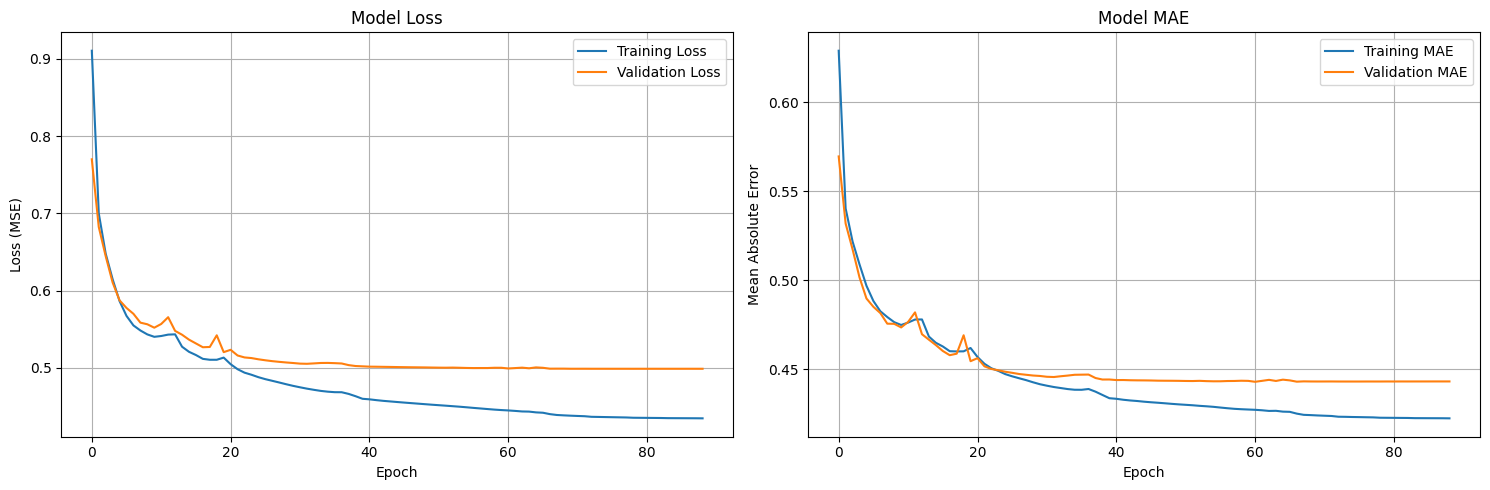

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Reconstruction quality:
Mean reconstruction error: 0.44784260563073536
Best reconstructed stock: NEM
Worst reconstructed stock: KDP


In [9]:
# Train autoencoder
epochs = 100
batch_size = 32
validation_split = 0.2

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("Training autoencoder...")
print("Epochs:", epochs)
print("Batch size:", batch_size)
print("Validation split:", validation_split)

history = autoencoder.fit(
    X, X,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\nTraining completed!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate reconstruction
reconstruction = autoencoder.predict(X)
reconstruction_error = np.mean((X - reconstruction) ** 2, axis=1)

print("\nReconstruction quality:")
print("Mean reconstruction error:", reconstruction_error.mean())
print("Best reconstructed stock:", selected_tickers[reconstruction_error.argmin()])
print("Worst reconstructed stock:", selected_tickers[reconstruction_error.argmax()])


## Extract Embeddings


In [ ]:
# Extract embeddings (encoded representations) for each stock
embeddings = encoder.predict(X)

print("Extracted embeddings:", embeddings.shape)
print("Shape: (n_stocks=" + str(embeddings.shape[0]) + ", embedding_dim=" + str(embeddings.shape[1]) + ")")

# Create DataFrame for easier manipulation
embeddings_df = pd.DataFrame(
    embeddings,
    index=selected_tickers,
    columns=['emb_' + str(i) for i in range(embeddings.shape[1])]
)

print("\nEmbeddings DataFrame:")
display(embeddings_df.head(10))

# Save embeddings
embeddings_df.to_csv('./dataset/autoencoder_embeddings.csv')
print("\nSaved embeddings to: ./dataset/autoencoder_embeddings.csv")


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Extracted embeddings: (432, 10)
Shape: (n_stocks=432, embedding_dim=10)

Embeddings DataFrame:


,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9
GNRC,1.359899,0.0,0.000000,0.0,13.976716,37.021694,0.0,0.0,0.0,13.608259
CHTR,14.619196,0.0,1.341446,0.0,18.153091,25.481148,0.0,0.0,0.0,5.764083
MTCH,1.846629,0.0,0.000000,0.0,18.739773,31.388260,0.0,0.0,0.0,2.541281
NDAQ,17.078701,0.0,0.000000,0.0,27.306103,38.215916,0.0,0.0,0.0,15.921999
WFC,34.005066,0.0,3.515214,0.0,1.317312,38.787273,0.0,0.0,0.0,24.403097
WM,33.724155,0.0,0.823892,0.0,29.795210,27.481207,0.0,0.0,0.0,22.498556
WELL,55.663525,0.0,8.129241,0.0,8.820193,20.144577,0.0,0.0,0.0,0.000000
WMB,28.658541,0.0,23.909805,0.0,2.558773,19.219606,0.0,0.0,0.0,20.420080
MU,0.000000,0.0,0.000000,0.0,0.206326,46.578667,0.0,0.0,0.0,8.109414
NDSN,8.731778,0.0,0.000000,0.0,15.191365,46.233101,0.0,0.0,0.0,22.334929



Saved embeddings to: ./dataset/autoencoder_embeddings.csv


## KMeans Clustering


In [ ]:
# Determine optimal number of clusters using silhouette score
cluster_range = range(4, 7)
silhouette_scores = []

print("Finding optimal number of clusters...")

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    silhouette_avg = silhouette_score(embeddings, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print("n_clusters=" + str(n_clusters) + ": silhouette_score=" + str(silhouette_avg))

# Select best number of clusters
optimal_clusters = cluster_range[np.argmax(silhouette_scores)]
print("\nOptimal number of clusters:", optimal_clusters)

# Final clustering with optimal number
kmeans_final = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(embeddings)

# Add cluster labels to embeddings DataFrame
embeddings_df['cluster'] = cluster_labels

# Show cluster distribution
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print("\nCluster distribution:")
for cluster_id, count in cluster_counts.items():
    stocks_in_cluster = embeddings_df[embeddings_df['cluster'] == cluster_id].index.tolist()
    print("Cluster " + str(cluster_id) + ":", count, "stocks")
    print("  " + ', '.join(stocks_in_cluster[:10]) + ('...' if len(stocks_in_cluster) > 10 else ''))

# Show sectors in each cluster
print("\nSector distribution within clusters:")
for cluster_id in range(optimal_clusters):
    stocks_in_cluster = embeddings_df[embeddings_df['cluster'] == cluster_id].index.tolist()
    sectors_in_cluster = [stock_sectors.get(t, 'Unknown') for t in stocks_in_cluster]
    sector_counts = pd.Series(sectors_in_cluster).value_counts()
    print("\nCluster " + str(cluster_id) + " (" + str(len(stocks_in_cluster)) + " stocks):")
    for sector, count in sector_counts.items():
        print("  " + sector + ":", count)


Finding optimal number of clusters...
n_clusters=4: silhouette_score=0.2776239812374115
n_clusters=5: silhouette_score=0.26041173934936523
n_clusters=6: silhouette_score=0.24943949282169342

Optimal number of clusters: 4

Cluster distribution:
Cluster 0: 194 stocks
  GNRC, CHTR, MTCH, NDAQ, MU, NDSN, MTD, TROW, MSI, MSFT...
Cluster 1: 92 stocks
  WFC, WMB, MTB, MS, MOS, NEM, OMC, OKE, NUE, NTRS...
Cluster 2: 93 stocks
  WM, WMT, MRK, TSN, VZ, WBA, NOC, MOH, MO, LLY...
Cluster 3: 53 stocks
  WELL, NEE, WEC, O, NRG, NI, XEL, LNT, MAA, WRB...

Sector distribution within clusters:

Cluster 0 (194 stocks):
  Industrials: 47
  Information Technology: 45
  Consumer Discretionary: 34
  Financials: 18
  Materials: 16
  Unknown: 14
  Communication Services: 9
  Healthcare: 9
  Real Estate: 1
  Consumer Staples: 1

Cluster 1 (92 stocks):
  Financials: 41
  Energy: 16
  Consumer Discretionary: 9
  Industrials: 8
  Materials: 6
  Communication Services: 5
  Unknown: 3
  Real Estate: 2
  Consumer St

## PCA Visualization


PCA transformation completed
Explained variance ratio: 0.727376
PC1: 0.49058932
PC2: 0.23678666


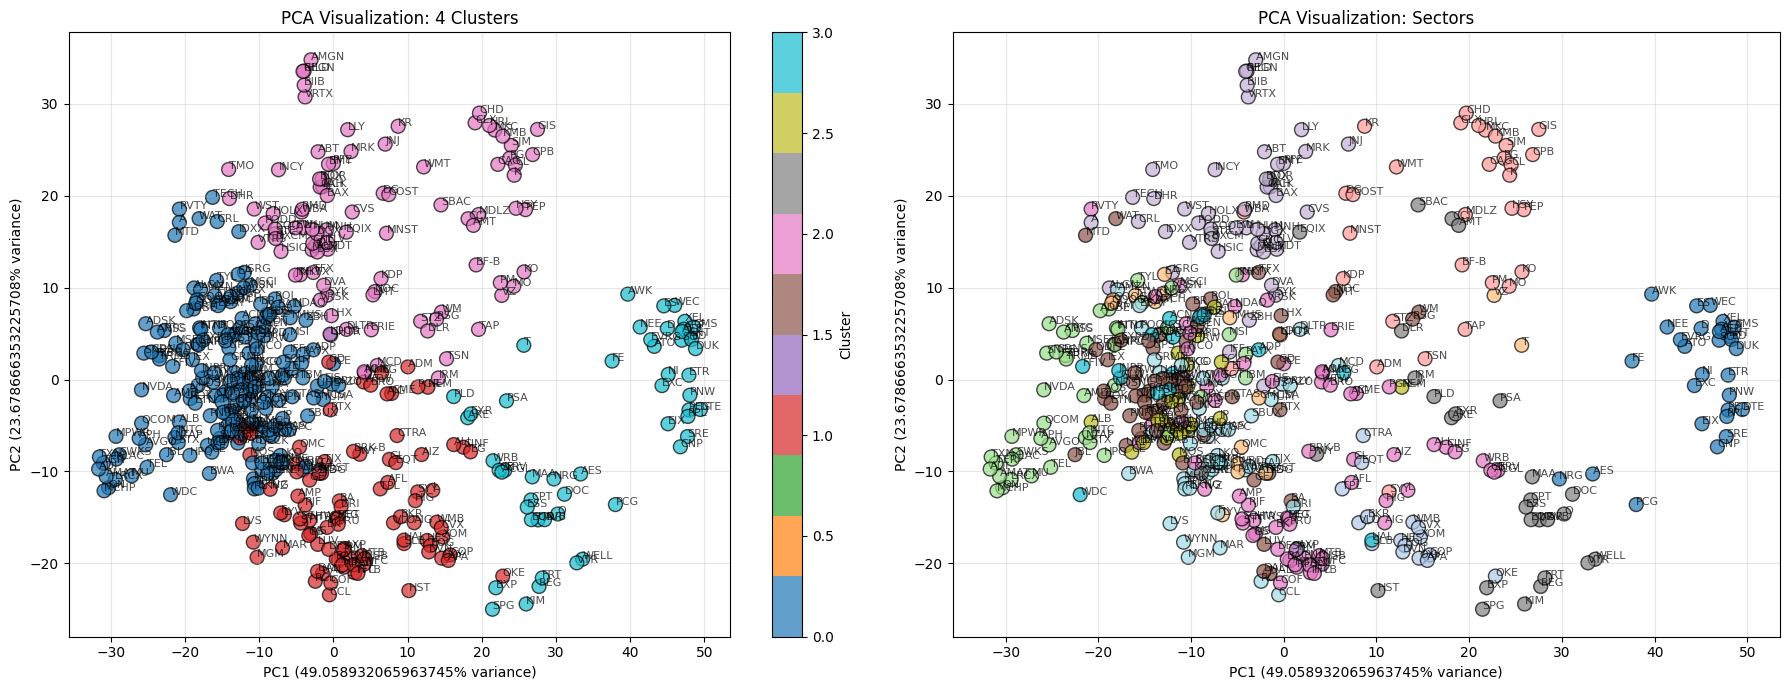


Saved PCA results to: ./dataset/pca_embeddings.csv


In [ ]:
# Reduce embeddings to 2D using PCA for visualization
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

print("PCA transformation completed")
print("Explained variance ratio:", pca.explained_variance_ratio_.sum())
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Clusters
scatter1 = axes[0].scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=cluster_labels, 
    cmap='tab10',
    s=100,
    alpha=0.7,
    edgecolors='black'
)

for i, ticker in enumerate(selected_tickers):
    axes[0].annotate(ticker, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                    fontsize=8, alpha=0.7)

axes[0].set_title('PCA Visualization: ' + str(optimal_clusters) + ' Clusters')
axes[0].set_xlabel('PC1 (' + str(pca.explained_variance_ratio_[0]*100) + '% variance)')
axes[0].set_ylabel('PC2 (' + str(pca.explained_variance_ratio_[1]*100) + '% variance)')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Sectors
sector_to_color = {sector: i for i, sector in enumerate(set(stock_sectors.values()))}
sector_colors = [sector_to_color.get(stock_sectors.get(t, 'Unknown'), -1) 
                for t in selected_tickers]

scatter2 = axes[1].scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=sector_colors, 
    cmap='tab20',
    s=100,
    alpha=0.7,
    edgecolors='black'
)

for i, ticker in enumerate(selected_tickers):
    axes[1].annotate(ticker, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                    fontsize=8, alpha=0.7)

axes[1].set_title('PCA Visualization: Sectors')
axes[1].set_xlabel('PC1 (' + str(pca.explained_variance_ratio_[0]*100) + '% variance)')
axes[1].set_ylabel('PC2 (' + str(pca.explained_variance_ratio_[1]*100) + '% variance)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save PCA results
pca_df = pd.DataFrame(
    embeddings_2d,
    index=selected_tickers,
    columns=['PC1', 'PC2']
)
pca_df['cluster'] = cluster_labels
pca_df.to_csv('./dataset/pca_embeddings.csv')
print("\nSaved PCA results to: ./dataset/pca_embeddings.csv")


## t-SNE Visualization


Computing t-SNE embedding (this may take a few minutes)...
t-SNE transformation completed


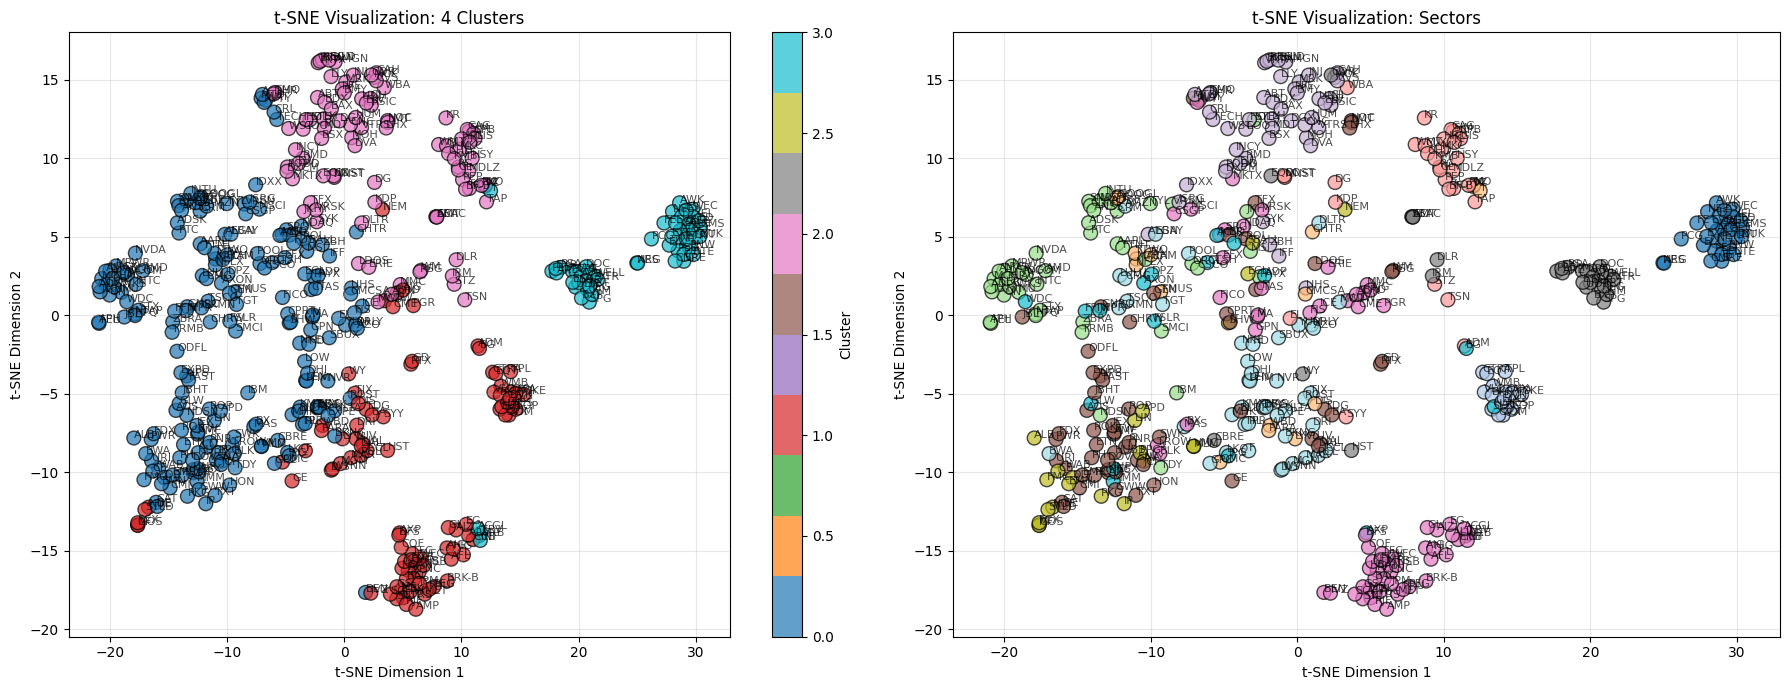


Saved t-SNE results to: ./dataset/tsne_embeddings.csv


In [ ]:
# Use t-SNE for non-linear dimensionality reduction
print("Computing t-SNE embedding (this may take a few minutes)...")

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(selected_tickers)-1))
embeddings_tsne = tsne.fit_transform(embeddings)

print("t-SNE transformation completed")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Clusters
scatter1 = axes[0].scatter(
    embeddings_tsne[:, 0], 
    embeddings_tsne[:, 1], 
    c=cluster_labels, 
    cmap='tab10',
    s=100,
    alpha=0.7,
    edgecolors='black'
)

for i, ticker in enumerate(selected_tickers):
    axes[0].annotate(ticker, (embeddings_tsne[i, 0], embeddings_tsne[i, 1]), 
                    fontsize=8, alpha=0.7)

axes[0].set_title('t-SNE Visualization: ' + str(optimal_clusters) + ' Clusters')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Sectors
scatter2 = axes[1].scatter(
    embeddings_tsne[:, 0], 
    embeddings_tsne[:, 1], 
    c=sector_colors, 
    cmap='tab20',
    s=100,
    alpha=0.7,
    edgecolors='black'
)

for i, ticker in enumerate(selected_tickers):
    axes[1].annotate(ticker, (embeddings_tsne[i, 0], embeddings_tsne[i, 1]), 
                    fontsize=8, alpha=0.7)

axes[1].set_title('t-SNE Visualization: Sectors')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save t-SNE results
tsne_df = pd.DataFrame(
    embeddings_tsne,
    index=selected_tickers,
    columns=['TSNE1', 'TSNE2']
)
tsne_df['cluster'] = cluster_labels
tsne_df.to_csv('./dataset/tsne_embeddings.csv')
print("\nSaved t-SNE results to: ./dataset/tsne_embeddings.csv")


## Select Candidate Pairs Within Clusters


In [ ]:
# Select candidate pairs from within clusters
import itertools

cluster_pairs = []
pair_distances = []

for cluster_id in range(optimal_clusters):
    stocks_in_cluster = embeddings_df[embeddings_df['cluster'] == cluster_id].index.tolist()
    
    if len(stocks_in_cluster) >= 2:
        pairs_in_cluster = list(itertools.combinations(stocks_in_cluster, 2))
        
        for ticker1, ticker2 in pairs_in_cluster:
            emb1 = embeddings_df.loc[ticker1].drop('cluster').values
            emb2 = embeddings_df.loc[ticker2].drop('cluster').values
            distance = np.linalg.norm(emb1 - emb2)
            
            cluster_pairs.append({
                'ticker1': ticker1,
                'ticker2': ticker2,
                'cluster': cluster_id,
                'embedding_distance': distance,
                'sector1': stock_sectors.get(ticker1, 'Unknown'),
                'sector2': stock_sectors.get(ticker2, 'Unknown'),
                'same_sector': stock_sectors.get(ticker1, 'Unknown') == stock_sectors.get(ticker2, 'Unknown')
            })
            pair_distances.append(distance)

cluster_pairs_df = pd.DataFrame(cluster_pairs)

# Sort to prioritize same-sector pairs, then by embedding distance
# Convert same_sector to numeric for sorting (False=0, True=1), then negate so True comes first
cluster_pairs_df['same_sector_sort'] = cluster_pairs_df['same_sector'].astype(int)
cluster_pairs_df = cluster_pairs_df.sort_values(['same_sector_sort', 'embedding_distance'], ascending=[False, True])
cluster_pairs_df = cluster_pairs_df.drop('same_sector_sort', axis=1)

print("Found", len(cluster_pairs_df), "candidate pairs within clusters")
print("\nPair statistics:")
print("Total pairs:", len(cluster_pairs_df))
print("Same-sector pairs:", cluster_pairs_df['same_sector'].sum(), "(" + str(cluster_pairs_df['same_sector'].mean()*100) + "%)")
print("Average embedding distance:", cluster_pairs_df['embedding_distance'].mean())

# Select top-N candidate pairs (prioritizing same-sector pairs)
N = 20
top_pairs = cluster_pairs_df.head(N)

print("\nTop", N, "candidate pairs (prioritizing same-sector pairs):")

for idx, row in top_pairs.iterrows():
    same_sector_marker = "Same sector" if row['same_sector'] else "Cross sector"
    print("Cluster " + str(int(row['cluster'])) + ": " + row['ticker1'] + " (" + row['sector1'] + ")  <->  " + 
          row['ticker2'] + " (" + row['sector2'] + ")")
    print("  " + same_sector_marker + ", Embedding distance: " + str(row['embedding_distance']))
    print()

# Show top same-sector pairs separately
same_sector_pairs = cluster_pairs_df[cluster_pairs_df['same_sector'] == True].head(N)
if len(same_sector_pairs) > 0:
    print("\nTop", min(N, len(same_sector_pairs)), "same-sector pairs within clusters:")
    for idx, row in same_sector_pairs.iterrows():
        print("Cluster " + str(int(row['cluster'])) + ": " + row['ticker1'] + " (" + row['sector1'] + ")  <->  " + 
              row['ticker2'] + " (" + row['sector2'] + ")")
        print("  Embedding distance: " + str(row['embedding_distance']))
        print()

# Save candidate pairs
cluster_pairs_df.to_csv('./dataset/cluster_candidate_pairs.csv', index=False)
print("Saved candidate pairs to: ./dataset/cluster_candidate_pairs.csv")

# Cluster-wise summary
print("\nPairs per cluster:")
for cluster_id in range(optimal_clusters):
    cluster_pair_count = len(cluster_pairs_df[cluster_pairs_df['cluster'] == cluster_id])
    if cluster_pair_count > 0:
        same_sector_count = cluster_pairs_df[
            (cluster_pairs_df['cluster'] == cluster_id) & 
            (cluster_pairs_df['same_sector'] == True)
        ].shape[0]
        print("Cluster " + str(cluster_id) + ": " + str(cluster_pair_count) + " pairs (" + 
              str(same_sector_count) + " same-sector)")


Found 28563 candidate pairs within clusters

Pair statistics:
Total pairs: 28563
Same-sector pairs: 5925 (20.743619367713475%)
Average embedding distance: 21.437959904292327

Top 20 candidate pairs (prioritizing same-sector pairs):
Cluster 0: GOOGL (Communication Services)  <->  GOOG (Communication Services)
  Same sector, Embedding distance: 0.4305608860819843

Cluster 0: NSC (Industrials)  <->  UNP (Industrials)
  Same sector, Embedding distance: 0.4635085292548472

Cluster 0: NSC (Industrials)  <->  CSX (Industrials)
  Same sector, Embedding distance: 0.756815430789459

Cluster 0: LEN (Consumer Discretionary)  <->  PHM (Consumer Discretionary)
  Same sector, Embedding distance: 0.8614426113170789

Cluster 1: RF (Financials)  <->  HBAN (Financials)
  Same sector, Embedding distance: 0.9133096317105374

Cluster 0: UNP (Industrials)  <->  CSX (Industrials)
  Same sector, Embedding distance: 1.0883062568748696

Cluster 3: AEP (Utilities)  <->  AEE (Utilities)
  Same sector, Embedding di

## Summary and Results


In [ ]:
print("\nCompleted ML Discovery (Autoencoder + Clustering)")
print("\nResults:")
print("  Stocks analyzed:", len(selected_tickers))
print("  Embedding dimension:", embeddings.shape[1])
print("  Optimal clusters:", optimal_clusters)
print("  Candidate pairs found:", len(cluster_pairs_df))
print("  Same-sector pairs:", cluster_pairs_df['same_sector'].sum())


# Create cluster summary
cluster_summary = []
for cluster_id in range(optimal_clusters):
    stocks_in_cluster = embeddings_df[embeddings_df['cluster'] == cluster_id].index.tolist()
    sectors = [stock_sectors.get(t, 'Unknown') for t in stocks_in_cluster]
    cluster_summary.append({
        'cluster': cluster_id,
        'n_stocks': len(stocks_in_cluster),
        'stocks': ', '.join(stocks_in_cluster),
        'dominant_sector': pd.Series(sectors).mode()[0] if len(sectors) > 0 else 'Unknown',
        'sectors': ', '.join(set(sectors))
    })

cluster_summary_df = pd.DataFrame(cluster_summary)
display(cluster_summary_df)



Completed ML Discovery (Autoencoder + Clustering)

Results:
  Stocks analyzed: 432
  Embedding dimension: 10
  Optimal clusters: 4
  Candidate pairs found: 28563
  Same-sector pairs: 5925


,cluster,n_stocks,stocks,dominant_sector,sectors
0,0,194,"GNRC, CHTR, MTCH, NDAQ, MU, NDSN, MTD, TROW, M...",Industrials,"Healthcare, Communication Services, Informatio..."
1,1,92,"WFC, WMB, MTB, MS, MOS, NEM, OMC, OKE, NUE, NT...",Financials,"Energy, Communication Services, Consumer Stapl..."
2,2,93,"WM, WMT, MRK, TSN, VZ, WBA, NOC, MOH, MO, LLY,...",Healthcare,"Healthcare, Communication Services, Consumer S..."
3,3,53,"WELL, NEE, WEC, O, NRG, NI, XEL, LNT, MAA, WRB...",Utilities,"Utilities, Communication Services, Financials,..."
